# Model 1: EfficientNet-B0 Baseline (Separate Models)

## Setup & Imports

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models, transforms
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score
)
from tqdm import tqdm

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if hasattr(torch.backends, 'mps'):
    print(f'MPS available: {torch.backends.mps.is_available()}')

In [ ]:
# ── TEST MODE ──────────────────────────────────────────────────────────────
# Set TEST_MODE = True for a quick end-to-end check (1-2 minutes).
# Uses only TEST_SAMPLES images per split so the whole notebook completes fast.
TEST_MODE = False
TEST_SAMPLES = 200  # images per split used when TEST_MODE is True
# ───────────────────────────────────────────────────────────────────────────

DATA_DIR = '../data/raw'
MODEL_SAVE_DIR = '../models/model1_efficientnet'
RESULTS_DIR = '../results/model1'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

CROSS_OUT_TYPES = ['SINGLE_LINE', 'DOUBLE_LINE', 'DIAGONAL', 'CROSS', 'WAVE', 'ZIG_ZAG', 'SCRATCH']
CROSS_OUT_LABELS = ['Single-Line', 'Double-Line', 'Diagonal', 'Cross', 'Wave', 'Zig-zag', 'Scratch']
NUM_CLASSES = len(CROSS_OUT_TYPES)

IMG_SIZE = 224
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]

# These are overridden in test mode
BATCH_SIZE = 16    if TEST_MODE else 64
NUM_EPOCHS = 2     if TEST_MODE else 50

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 5
SCHEDULER_PATIENCE = 3
SCHEDULER_FACTOR = 0.5
NUM_WORKERS = 4  # Set to 4 on Linux/Colab with CUDA. Must be 0 on macOS notebooks.
PIN_MEMORY = True if torch.cuda.is_available() else False

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

if TEST_MODE:
    print('  TEST MODE ENABLED — quick end-to-end check (~1-2 min)')
    print(f'  Samples per split : {TEST_SAMPLES}')
    print(f'  Epochs            : {NUM_EPOCHS}')
    print(f'  Batch size        : {BATCH_SIZE}')
    print('  Set TEST_MODE = False for full GPU training.')
else:
    print('FULL TRAINING MODE')
print(f'Device: {DEVICE} | Batch: {BATCH_SIZE} | Epochs: {NUM_EPOCHS}')
print(f'Data directory: {os.path.abspath(DATA_DIR)}')

FULL TRAINING MODE
Device: cuda | Batch: 64 | Epochs: 50
Data directory: /project/crossout-detection/data/raw


## Dataset & DataLoaders

In [ ]:
# Augmentation pipeline (torchvision, baseline without Elastic/Morphological)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

In [ ]:
class CrossOutDataset(Dataset):
    """Dataset for cross-out detection and classification."""

    def __init__(self, data_dir, split='train', task='binary', transform=None):
        self.data_dir = os.path.join(data_dir, split, 'images')
        self.task = task
        self.transform = transform
        self.images = []
        self.labels = []

        if task == 'binary':
            self._load_binary()
        elif task == 'multiclass':
            self._load_multiclass()

    def _load_binary(self):
        # Clean images -> label 0
        clean_dir = os.path.join(self.data_dir, 'CLEAN')
        if os.path.exists(clean_dir):
            for fname in os.listdir(clean_dir):
                if self._is_image(fname):
                    self.images.append(os.path.join(clean_dir, fname))
                    self.labels.append(0)

        # Cross-out images -> label 1 (all 7 types + MIXED)
        binary_folders = CROSS_OUT_TYPES + ['MIXED']
        for cross_type in binary_folders:
            type_dir = os.path.join(self.data_dir, cross_type)
            if os.path.exists(type_dir):
                for fname in os.listdir(type_dir):
                    if self._is_image(fname):
                        self.images.append(os.path.join(type_dir, fname))
                        self.labels.append(1)

    def _load_multiclass(self):
        # MIXED is excluded here — no per-image type label available
        for idx, cross_type in enumerate(CROSS_OUT_TYPES):
            type_dir = os.path.join(self.data_dir, cross_type)
            if os.path.exists(type_dir):
                for fname in os.listdir(type_dir):
                    if self._is_image(fname):
                        self.images.append(os.path.join(type_dir, fname))
                        self.labels.append(idx)

    def _is_image(self, fname):
        return fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

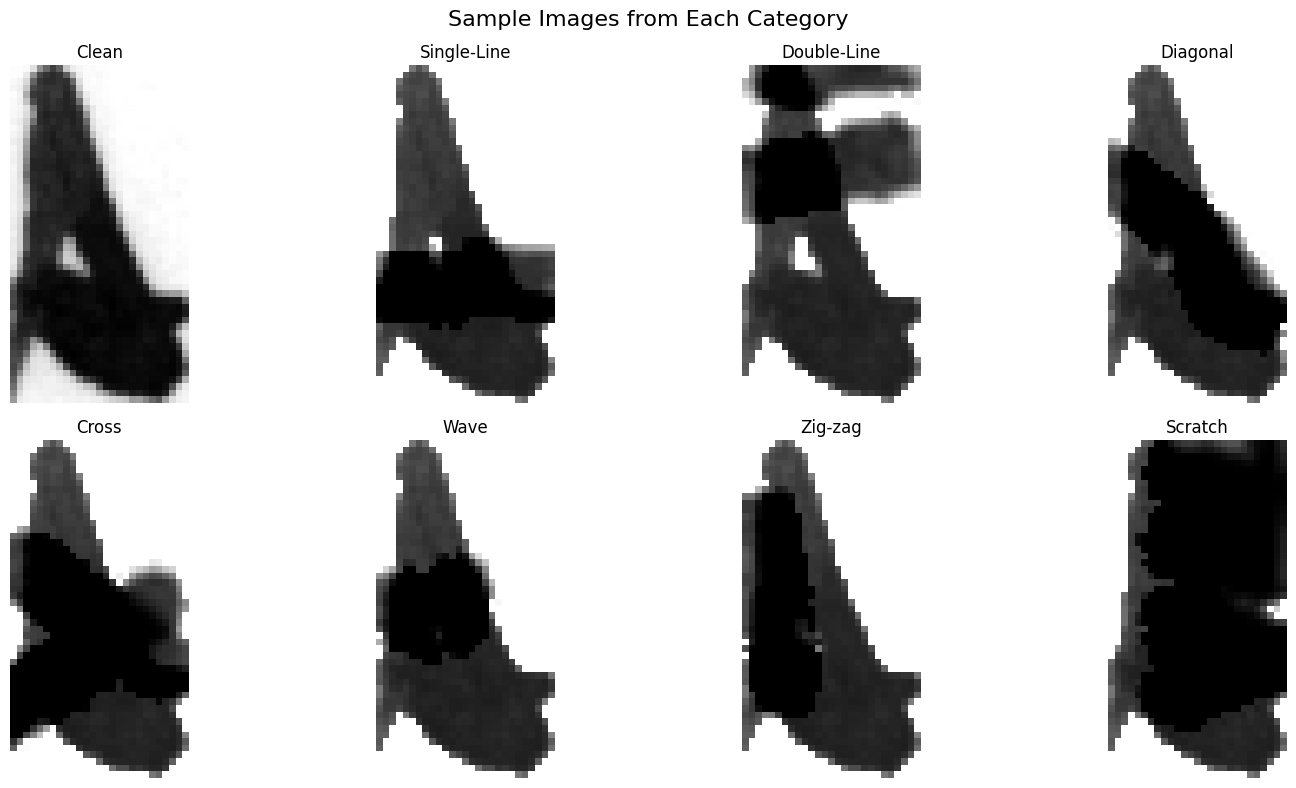

In [6]:
# Show sample images from each cross-out type
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
folders = ['CLEAN'] + CROSS_OUT_TYPES
labels = ['Clean'] + CROSS_OUT_LABELS

for i, (folder, label) in enumerate(zip(folders[:8], labels[:8])):
    ax = axes[i // 4][i % 4]
    img_dir = os.path.join(DATA_DIR, 'train', 'images', folder)
    if os.path.exists(img_dir):
        img_name = sorted(os.listdir(img_dir))[0]
        img = Image.open(os.path.join(img_dir, img_name))
        ax.imshow(img, cmap='gray')
    ax.set_title(label, fontsize=12)
    ax.axis('off')

plt.suptitle('Sample Images from Each Category', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_images.png'), dpi=150)
plt.show()

In [ ]:
# ── Dataset Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Binary classification distribution (includes MIXED in crossed-out) ---
binary_data = {'Clean': [], 'Crossed-out': []}
for split in ['train', 'val', 'test']:
    clean_dir = os.path.join(DATA_DIR, split, 'images', 'CLEAN')
    clean_count = len([f for f in os.listdir(clean_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]) if os.path.exists(clean_dir) else 0
    cross_count = 0
    for ct in CROSS_OUT_TYPES + ['MIXED']:
        ct_dir = os.path.join(DATA_DIR, split, 'images', ct)
        if os.path.exists(ct_dir):
            cross_count += len([f for f in os.listdir(ct_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    binary_data['Clean'].append(clean_count)
    binary_data['Crossed-out'].append(cross_count)

x = np.arange(3)
width = 0.35
bars1 = axes[0].bar(x - width/2, binary_data['Clean'], width, label='Clean', color='#2ecc71')
bars2 = axes[0].bar(x + width/2, binary_data['Crossed-out'], width, label='Crossed-out', color='#e74c3c')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Train', 'Val', 'Test'])
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Task 1: Binary Classification — Class Distribution', fontsize=13)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

# --- Cross-out type distribution (train split) ---
type_counts = []
for ct in CROSS_OUT_TYPES:
    ct_dir = os.path.join(DATA_DIR, 'train', 'images', ct)
    count = len([f for f in os.listdir(ct_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]) if os.path.exists(ct_dir) else 0
    type_counts.append(count)

colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6', '#1abc9c', '#f39c12']
bars = axes[1].bar(CROSS_OUT_LABELS, type_counts, color=colors)
axes[1].set_ylabel('Number of Images')
axes[1].set_title('Task 2: Cross-out Types — Train Distribution', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dataset_distribution.png'), dpi=150)
plt.show()

# Print summary
total_binary = binary_data['Clean'][0] + binary_data['Crossed-out'][0]
print(f'\nBinary Task — Train split (includes MIXED):')
print(f'  Clean:       {binary_data["Clean"][0]:>8,}  ({binary_data["Clean"][0]/total_binary*100:.1f}%)')
print(f'  Crossed-out: {binary_data["Crossed-out"][0]:>8,}  ({binary_data["Crossed-out"][0]/total_binary*100:.1f}%)  [7 types + MIXED]')
print(f'  Imbalance ratio: 1 : {binary_data["Crossed-out"][0] / binary_data["Clean"][0]:.1f}')
print(f'\nMulticlass Task — Train split (MIXED excluded, no type label):')
for label, count in zip(CROSS_OUT_LABELS, type_counts):
    print(f'  {label:<12}: {count:>8,}')
print(f'  All types balanced: {len(set(type_counts)) == 1}')

## Model Architecture

In [7]:
class EfficientNetClassifier(nn.Module):
    """EfficientNet-B0 for single-task classification."""

    def __init__(self, num_classes=1):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = self.backbone.classifier[1].in_features  # 1280
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

    def get_backbone_state_dict(self):
        return self.backbone.features.state_dict()

# Quick check
model_test = EfficientNetClassifier(num_classes=1)
total_params = sum(p.numel() for p in model_test.parameters())
trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
del model_test

Total parameters: 4,008,829
Trainable parameters: 4,008,829


## Training Functions

In [8]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = None

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            return False
        self.counter += 1
        if self.counter >= self.patience:
            print(f'Early stopping triggered after {self.counter} epochs without improvement.')
            return True
        return False

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, task, scaler=None):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    use_amp = scaler is not None

    for images, labels in tqdm(dataloader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            if task == 'binary':
                outputs = outputs.squeeze(1)
                loss = criterion(outputs, labels.float())
            else:
                loss = criterion(outputs, labels)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            if task == 'binary':
                preds = (torch.sigmoid(outputs) > 0.5).long()
            else:
                preds = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def validate(model, dataloader, criterion, device, task, use_amp=False):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validating', leave=False):
            images, labels = images.to(device), labels.to(device)

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(images)
                if task == 'binary':
                    outputs = outputs.squeeze(1)
                    loss = criterion(outputs, labels.float())
                    preds = (torch.sigmoid(outputs) > 0.5).long()
                else:
                    loss = criterion(outputs, labels)
                    preds = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [ ]:
def train_model(model, train_loader, val_loader, task, save_path, model_name='model1'):
    device = torch.device(DEVICE)
    model = model.to(device)

    criterion = nn.BCEWithLogitsLoss() if task == 'binary' else nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=SCHEDULER_PATIENCE, factor=SCHEDULER_FACTOR)
    early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)

    # Mixed precision: only on CUDA (not supported on MPS/CPU)
    use_amp = (DEVICE == 'cuda')
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if use_amp else None
    if use_amp:
        print('Mixed precision (AMP) enabled — ~1.5-2x faster on CUDA')

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    best_val_loss = float('inf')
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f'\nTraining {model_name} - Task: {task}')
    print(f'Device: {device}')
    print(f'Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}')
    print('-' * 60)

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, task, scaler=scaler)
        val_loss, val_acc = validate(model, val_loader, criterion, device, task, use_amp=use_amp)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | LR: {lr:.6f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f'  -> Best model saved')

        if early_stopping(val_loss):
            break

    print(f'\nTraining complete. Best Val Loss: {best_val_loss:.4f}')

    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    return model, history

## Evaluation Functions

In [ ]:
def get_predictions(model, dataloader, task):
    device = torch.device(DEVICE)
    use_amp = (DEVICE == 'cuda')
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Evaluating', leave=False):
            images = images.to(device)

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(images)

            if task == 'binary':
                probs = torch.sigmoid(outputs.squeeze(1)).cpu().numpy()
                preds = (probs > 0.5).astype(int)
            else:
                probs = torch.softmax(outputs, dim=1).cpu().numpy()
                preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [12]:
def plot_confusion_matrix(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title, fontsize=14)
    plt.colorbar(im)

    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black')

    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    return fig


def plot_training_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

## Task 1: Binary Classification (Clean vs Crossed-out)

  Binary class distribution: Clean=47,997, Crossed-out=335,979
  Using WeightedRandomSampler to balance classes
Task: binary  
  Train: 383,976 images
  Val:   60,472 images
  Test:  162,448 images

Training model1 - Task: binary
Device: cuda
Epochs: 50 | Batch: 64 | LR: 0.0001
------------------------------------------------------------


Epoch [1/50] Train Loss: 0.0782 Acc: 0.9501 | Val Loss: 0.0804 Acc: 0.9752 | LR: 0.000100
  -> Best model saved


Epoch [2/50] Train Loss: 0.0705 Acc: 0.9516 | Val Loss: 0.0820 Acc: 0.9054 | LR: 0.000100


Epoch [3/50] Train Loss: 0.0695 Acc: 0.9518 | Val Loss: 0.0802 Acc: 0.9777 | LR: 0.000100
  -> Best model saved


Epoch [4/50] Train Loss: 0.0692 Acc: 0.9515 | Val Loss: 0.0820 Acc: 0.9767 | LR: 0.000100


Epoch [5/50] Train Loss: 0.0691 Acc: 0.9519 | Val Loss: 0.0955 Acc: 0.9045 | LR: 0.000100


Epoch [6/50] Train Loss: 0.0679 Acc: 0.9528 | Val Loss: 0.0830 Acc: 0.9043 | LR: 0.000100


Epoch [7/50] Train Loss: 0.0680 Acc: 0.9526 | Val Loss: 0.0839 Acc: 0.9047 | LR: 0.000050


Epoch [8/50] Train Loss: 0.0674 Acc: 0.9522 | Val Loss: 0.0861 Acc: 0.9051 | LR: 0.000050
Early stopping triggered after 5 epochs without improvement.

Training complete. Best Val Loss: 0.0802


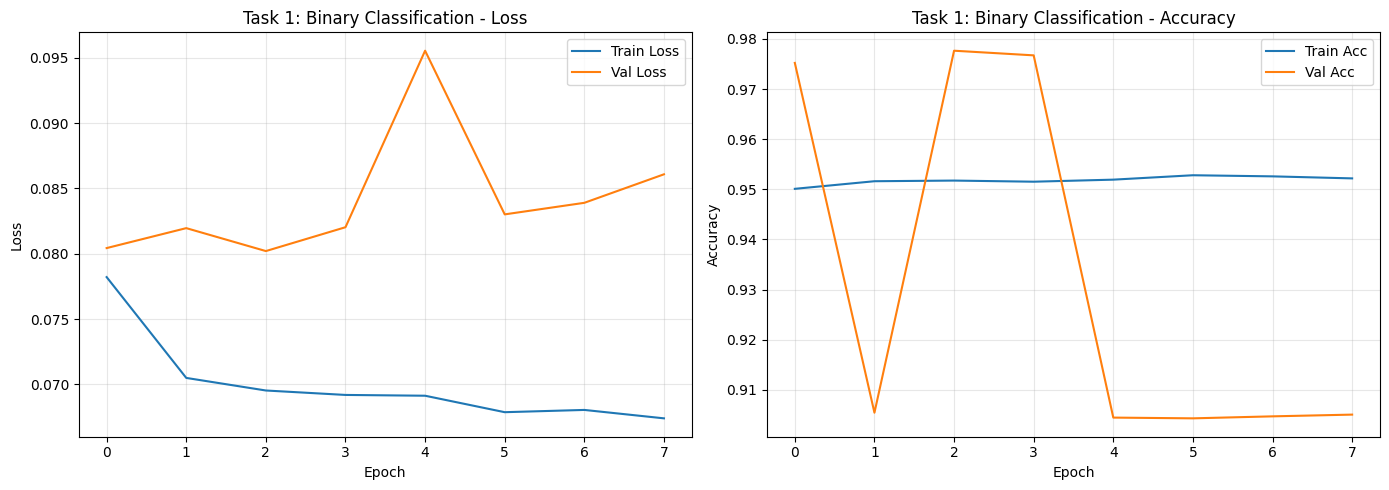

In [13]:
train_loader_t1, val_loader_t1, test_loader_t1 = get_dataloaders(task='binary')
model_t1 = EfficientNetClassifier(num_classes=1)
task1_save_path = os.path.join(MODEL_SAVE_DIR, 'task1_best.pth')

model_t1, history_t1 = train_model(
    model_t1, train_loader_t1, val_loader_t1,
    task='binary', save_path=task1_save_path, model_name='model1'
)
fig = plot_training_history(history_t1, 'Task 1: Binary Classification')
fig.savefig(os.path.join(RESULTS_DIR, 'task1_training_curves.png'), dpi=150)
plt.show()

### Evaluate on Test Set

In [14]:
labels_t1, preds_t1, probs_t1 = get_predictions(model_t1, test_loader_t1, task='binary')

results_t1 = {
    'accuracy': accuracy_score(labels_t1, preds_t1),
    'f1_score': f1_score(labels_t1, preds_t1),
    'precision': precision_score(labels_t1, preds_t1),
    'recall': recall_score(labels_t1, preds_t1),
    'auc_roc': roc_auc_score(labels_t1, probs_t1),
}

print('=== Task 1: Binary Classification Results ===')
for metric, value in results_t1.items():
    print(f'  {metric}: {value:.4f}')

=== Task 1: Binary Classification Results ===
  accuracy: 0.9798
  f1_score: 0.9885
  precision: 0.9870
  recall: 0.9899
  auc_roc: 0.9949


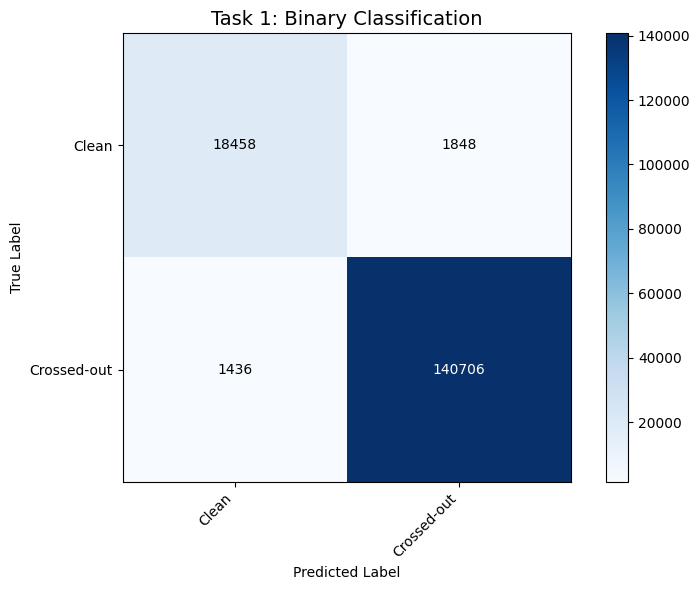

In [15]:
cm_t1 = confusion_matrix(labels_t1, preds_t1)
fig = plot_confusion_matrix(cm_t1, ['Clean', 'Crossed-out'], 'Task 1: Binary Classification')
fig.savefig(os.path.join(RESULTS_DIR, 'task1_confusion_matrix.png'), dpi=150)
plt.show()

## Task 2: Multi-class Classification (7 Cross-out Types)

Task: multiclass  
  Train: 335,979 images
  Val:   52,913 images
  Test:  142,142 images

Training model1 - Task: multiclass
Device: cuda
Epochs: 50 | Batch: 64 | LR: 0.0001
------------------------------------------------------------


Epoch [1/50] Train Loss: 0.3035 Acc: 0.8755 | Val Loss: 0.2471 Acc: 0.8937 | LR: 0.000100
  -> Best model saved


Epoch [2/50] Train Loss: 0.2264 Acc: 0.9036 | Val Loss: 0.2356 Acc: 0.8974 | LR: 0.000100
  -> Best model saved


Epoch [3/50] Train Loss: 0.2162 Acc: 0.9071 | Val Loss: 0.2357 Acc: 0.8983 | LR: 0.000100


Epoch [4/50] Train Loss: 0.2105 Acc: 0.9092 | Val Loss: 0.2323 Acc: 0.8990 | LR: 0.000100
  -> Best model saved


...

Epoch [13/50] Train Loss: 0.1926 Acc: 0.9156 | Val Loss: 0.2252 Acc: 0.9018 | LR: 0.000050
  -> Best model saved


Epoch [14/50] Train Loss: 0.1918 Acc: 0.9156 | Val Loss: 0.2264 Acc: 0.9018 | LR: 0.000050


Epoch [15/50] Train Loss: 0.1914 Acc: 0.9159 | Val Loss: 0.2278 Acc: 0.9016 | LR: 0.000050


Epoch [16/50] Train Loss: 0.1914 Acc: 0.9159 | Val Loss: 0.2274 Acc: 0.9017 | LR: 0.000050


Epoch [18/50] Train Loss: 0.1891 Acc: 0.9170 | Val Loss: 0.2276 Acc: 0.9024 | LR: 0.000025
Early stopping triggered after 5 epochs without improvement.

Training complete. Best Val Loss: 0.2252


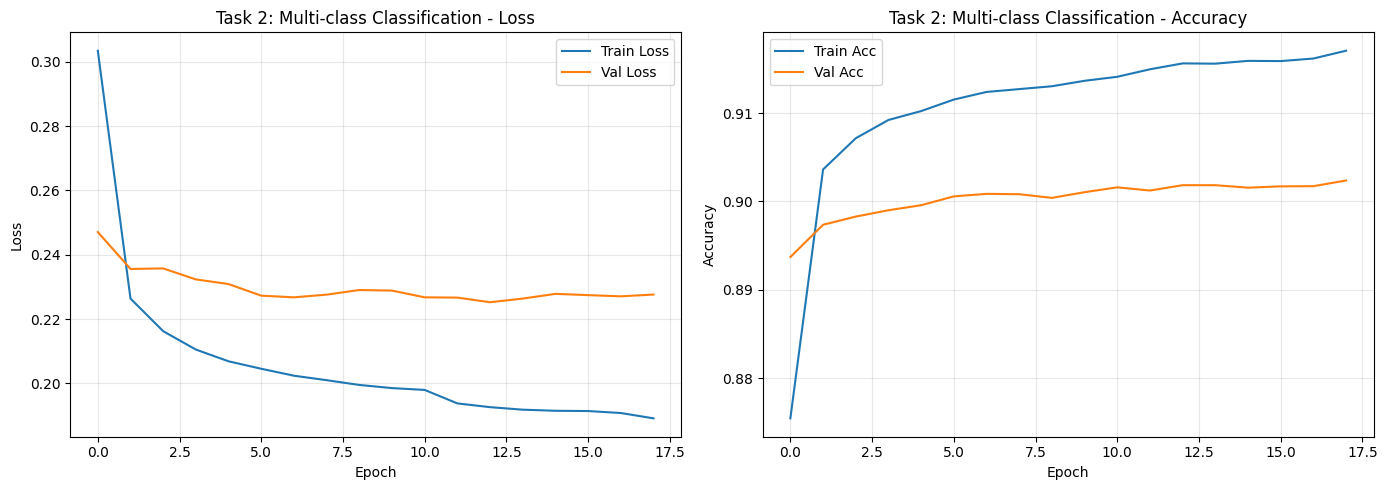

In [16]:
train_loader_t2, val_loader_t2, test_loader_t2 = get_dataloaders(task='multiclass')
model_t2 = EfficientNetClassifier(num_classes=NUM_CLASSES)
task2_save_path = os.path.join(MODEL_SAVE_DIR, 'task2_best.pth')

model_t2, history_t2 = train_model(
    model_t2, train_loader_t2, val_loader_t2,
    task='multiclass', save_path=task2_save_path, model_name='model1'
)
fig = plot_training_history(history_t2, 'Task 2: Multi-class Classification')
fig.savefig(os.path.join(RESULTS_DIR, 'task2_training_curves.png'), dpi=150)
plt.show()

### Evaluate on Test Set

In [17]:
labels_t2, preds_t2, probs_t2 = get_predictions(model_t2, test_loader_t2, task='multiclass')

results_t2 = {
    'accuracy': accuracy_score(labels_t2, preds_t2),
    'macro_f1': f1_score(labels_t2, preds_t2, average='macro'),
    'macro_precision': precision_score(labels_t2, preds_t2, average='macro'),
    'macro_recall': recall_score(labels_t2, preds_t2, average='macro'),
}

print('=== Task 2: Multi-class Classification Results ===')
for metric, value in results_t2.items():
    print(f'  {metric}: {value:.4f}')

print('\nPer-class Report:')
print(classification_report(labels_t2, preds_t2, target_names=CROSS_OUT_LABELS))

=== Task 2: Multi-class Classification Results ===
  accuracy: 0.9089
  macro_f1: 0.9136
  macro_precision: 0.9297
  macro_recall: 0.9089

Per-class Report:
              precision    recall  f1-score   support

 Single-Line       0.89      0.91      0.90     20306
 Double-Line       1.00      0.90      0.94     20306
    Diagonal       0.67      0.98      0.80     20306
       Cross       1.00      0.90      0.95     20306
        Wave       0.99      0.89      0.93     20306
     Zig-zag       0.98      0.89      0.93     20306
     Scratch       0.98      0.90      0.94     20306

    accuracy                           0.91    142142
   macro avg       0.93      0.91      0.91    142142
weighted avg       0.93      0.91      0.91    142142



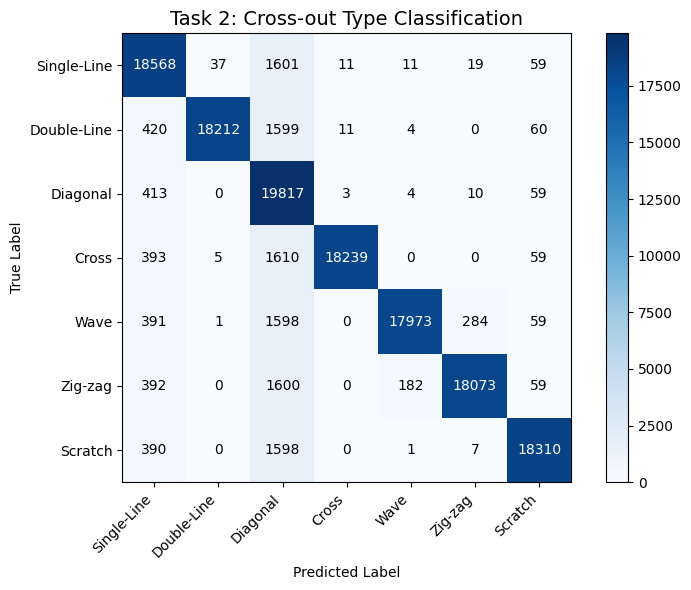

In [18]:
cm_t2 = confusion_matrix(labels_t2, preds_t2)
fig = plot_confusion_matrix(cm_t2, CROSS_OUT_LABELS, 'Task 2: Cross-out Type Classification')
fig.savefig(os.path.join(RESULTS_DIR, 'task2_confusion_matrix.png'), dpi=150)
plt.show()

### Save Backbone Weights (for other Models)

In [19]:
# Save both backbones with metadata
backbone_t1_path = os.path.join(MODEL_SAVE_DIR, 'backbone_task1.pth')
backbone_t2_path = os.path.join(MODEL_SAVE_DIR, 'backbone_task2.pth')
backbone_default_path = os.path.join(MODEL_SAVE_DIR, 'backbone.pth')

# Save with metadata so Model 2/3 know exactly what they're loading
def save_checkpoint(state_dict, path, metadata):
    checkpoint = {
        'state_dict': state_dict,
        'architecture': 'EfficientNet-B0',
        'img_size': IMG_SIZE,
        'img_mean': IMG_MEAN,
        'img_std': IMG_STD,
        **metadata
    }
    torch.save(checkpoint, path)

save_checkpoint(model_t1.get_backbone_state_dict(), backbone_t1_path,
    {'source_task': 'binary', 'source_accuracy': results_t1['accuracy']})

save_checkpoint(model_t2.get_backbone_state_dict(), backbone_t2_path,
    {'source_task': 'multiclass', 'source_accuracy': results_t2['accuracy']})

save_checkpoint(model_t1.get_backbone_state_dict(), backbone_default_path,
    {'source_task': 'binary (default)', 'source_accuracy': results_t1['accuracy']})

# Also save full task models with metadata
torch.save({
    'state_dict': model_t1.state_dict(),
    'architecture': 'EfficientNet-B0', 'task': 'binary',
    'num_classes': 1, 'results': results_t1,
    'img_size': IMG_SIZE, 'img_mean': IMG_MEAN, 'img_std': IMG_STD,
}, os.path.join(MODEL_SAVE_DIR, 'task1_final.pth'))

torch.save({
    'state_dict': model_t2.state_dict(),
    'architecture': 'EfficientNet-B0', 'task': 'multiclass',
    'num_classes': NUM_CLASSES, 'class_names': CROSS_OUT_LABELS, 'results': results_t2,
    'img_size': IMG_SIZE, 'img_mean': IMG_MEAN, 'img_std': IMG_STD,
}, os.path.join(MODEL_SAVE_DIR, 'task2_final.pth'))

print('Backbone weights saved (with metadata):')
print(f'  Task 1 backbone: {backbone_t1_path}')
print(f'  Task 2 backbone: {backbone_t2_path}')
print(f'  Default (Task 1): {backbone_default_path}')
print(f'\nFull model checkpoints:')
print(f'  {MODEL_SAVE_DIR}/task1_final.pth')
print(f'  {MODEL_SAVE_DIR}/task2_final.pth')
print('\nModel 2/3 can load backbone with:')
print("  checkpoint = torch.load('backbone.pth')")
print("  model.backbone.features.load_state_dict(checkpoint['state_dict'])")

Backbone weights saved (with metadata):
  Task 1 backbone: ../models/model1_efficientnet/backbone_task1.pth
  Task 2 backbone: ../models/model1_efficientnet/backbone_task2.pth
  Default (Task 1): ../models/model1_efficientnet/backbone.pth

Full model checkpoints:
  ../models/model1_efficientnet/task1_final.pth
  ../models/model1_efficientnet/task2_final.pth

Model 2/3 can load backbone with:
  checkpoint = torch.load('backbone.pth')
  model.backbone.features.load_state_dict(checkpoint['state_dict'])
